# Customer Segmentation using K-Means Clustering

## 1. Project Overview

Customer segmentation is one of the most common applications of unsupervised Machine Learning branch. Instead of predicting a target variable, clustering algorithms identify groups of customers that share similar characteristics.

From a business perspective, understanding customer segments allows companies to design more personalized marketing strategies, improve customer retention, optimize advertising campaigns, and allocate resources more efficiently.


## 2. Project Objectives
The main objective of this project is to identify meaningful customer segments using the K-Means clustering algorithm and translate the resulting clusters into actionable business insights.

General objectives of this project includes:

* Explore and understand customer demographic and purchasing behavior.
* Prepare the dataset for clustering.
* Determine an appropriate number of customer segments.
* Build a K-Means clustering model.
* Interpret each cluster from a business perspective.
* Provide marketing recommendations based on the identified customer groups.

## 3. Dataset
The dataset used in this project is the Customer Personality Analysis dataset available on Kaggle. It contains demographic information, purchasing behavior, and marketing campaign responses for customers of a retail company.

The objective of the dataset is to identify meaningful customer groups based on their purchasing habits and personal characteristics. By understanding these customer segments, businesses can develop more effective marketing strategies, personalize promotions, and improve customer engagement.

Rather than treating every customer in the same way, customer segmentation allows companies to identify groups with similar behaviors and preferences, making marketing efforts more efficient and data-driven.

The dataset contains 2,240 customer records and 29 variables, which can be grouped into four categories:


| Category      | Description                                                       |
| ------------- | ----------------------------------------------------------------- |
| **People**    | Customer demographic and socioeconomic characteristics.           |
| **Products**  | Amount spent on each product category during the last two years.  |
| **Promotion** | Customer responses to marketing campaigns and promotional offers. |
| **Place**     | Customer purchasing channels and website activity.                |

### 3.1 People Category
| Variable       | Description              |
| -------------- | ------------------------ |
| ID             | Customer identifier      |
| Year_Birth     | Birth year               |
| Education      | Education level          |
| Marital_Status | Marital status           |
| Income         | Annual household income  |
| Kidhome        | Number of children       |
| Teenhome       | Number of teenagers      |
| Dt_Customer    | Enrollment date          |
| Recency        | Days since last purchase |
| Complain       | Complaint indicator      |

### 3.2 Products Category

| Variable         | Description           |
| ---------------- | --------------------- |
| MntWines         | Wine spending         |
| MntFruits        | Fruit spending        |
| MntMeatProducts  | Meat spending         |
| MntFishProducts  | Fish spending         |
| MntSweetProducts | Sweet spending        |
| MntGoldProds     | Gold product spending |

### 3.3 Promotion Category

| Variable          | Description               |
|-------------------| ------------------------- |
| NumDealsPurchases | Purchases using discounts |
| AcceptedCmp1      | Accepted Campaign 1       |
| AcceptedCmp2      | Accepted Campaign 2       |
| AcceptedCmp3      | Accepted Campaign 3       |
| AcceptedCmp4      | Accepted Campaign 4       |
| AcceptedCmp5      | Accepted Campaign 5       |
| Response          | Accepted last campaign    |
| Z_CostContact     | Cost of contact used in campaign data    |
| Z_Revenue         | Revenue value used in campaign data      |

### 3.4 Place Category
| Variable            | Description                  |
| ------------------- | ---------------------------- |
| NumWebPurchases     | Purchases through website    |
| NumCatalogPurchases | Purchases through catalog    |
| NumStorePurchases   | Purchases in physical stores |
| NumWebVisitsMonth   | Website visits last month    |


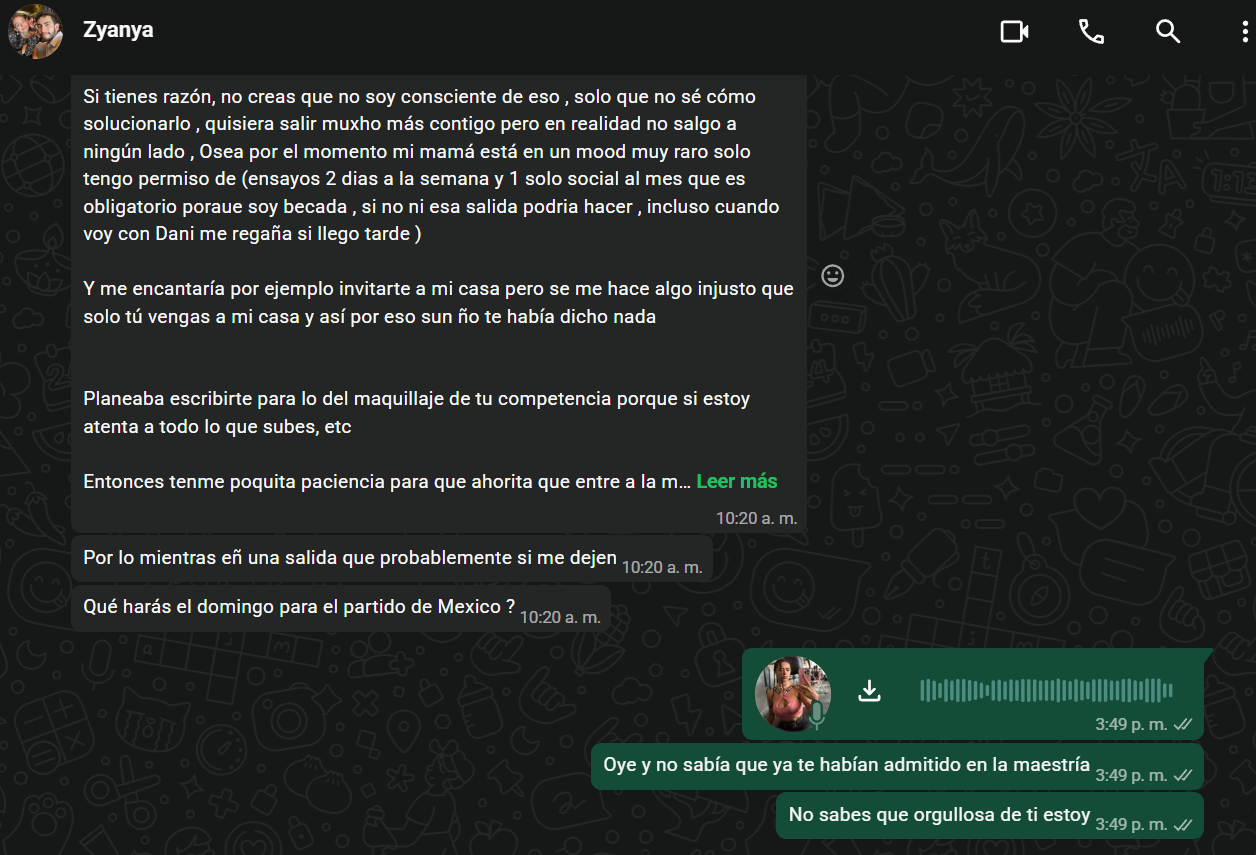

In [1]:
# Import libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

The following table shows the first five observations of the dataset.

In [2]:
# Load dataset
df = pd.read_csv("../data/marketing_campaign.csv", sep="\t")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [65]:
df.Z_CostContact

0       3
1       3
2       3
3       3
4       3
       ..
2235    3
2236    3
2237    3
2238    3
2239    3
Name: Z_CostContact, Length: 2240, dtype: int64

## 4. Exploratory Data Analysis
It is important to understand the structure of the dataset, including the number of observations, variable types, and the presence of missing values.
### 4.1 Dataset Structure

In [3]:
# Data general info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [4]:
# Dataset dimensions
df.shape

(2240, 29)

The dataset contains 2,240 observations and 29 variables.


In [5]:
# Data types
df.dtypes

ID                       int64
Year_Birth               int64
Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Dt_Customer             object
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Z_CostContact            int64
Z_Revenue                int64
Response                 int64
dtype: object

The dataset contains numerical variables (int64 and float64) together with three variables stored as object: Education, Marital_Status, and Dt_Customer. The latter represents enrollment dates but is currently stored as text rather than as a datetime object.

### 4.2  Numerical Variables Statistics


In [6]:
# Numerical summary
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


### 4.3 Categorical Variables Summary

In [7]:
# Categorical summary
df.describe(include='object')

,Education,Marital_Status,Dt_Customer
count,2240,2240,2240
unique,5,8,663
top,Graduation,Married,31-08-2012
freq,1127,864,12


### 4.4 Missing Values

In [9]:
# Missing values
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [8]:
missing_percentage = (
    df['Income'].isnull().mean() * 100
)

print(f"{missing_percentage:.2f}%")

1.07%


The dataset contains missing values only in the Income variable, with 24 missing observations (1.07% of the dataset). Since the proportion of missing data is very small and Income is expected to play an important role in customer segmentation, these records will be removed during the data preparation stage instead of being imputed.

### 4.5 Correlation Analysis

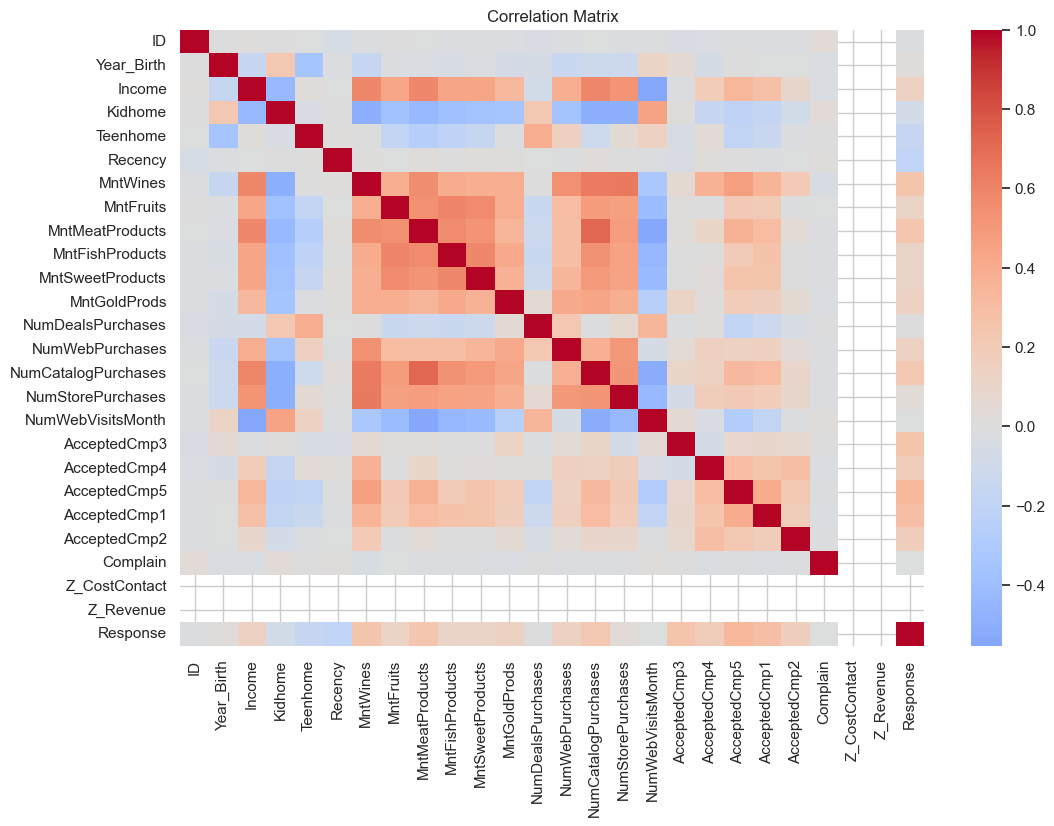

In [11]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

### 4.6 Category Analysis
After analyzing the general structure, distributions, missing values, and relationships between variables, we proceed with a category-based analysis to better understand customer behavior from a business perspective.

The variables are grouped into four categories defined by the dataset: People, Products, Promotion, and Place. This approach allows us to analyze different dimensions of customer behavior before applying the clustering algorithm.
#### 4.6.1 People Analysis
We would like to understand customer's demographics and socioeconomic characteristics in order to answer some questions: Who are our costumers? What is their age, education, income and household composition?



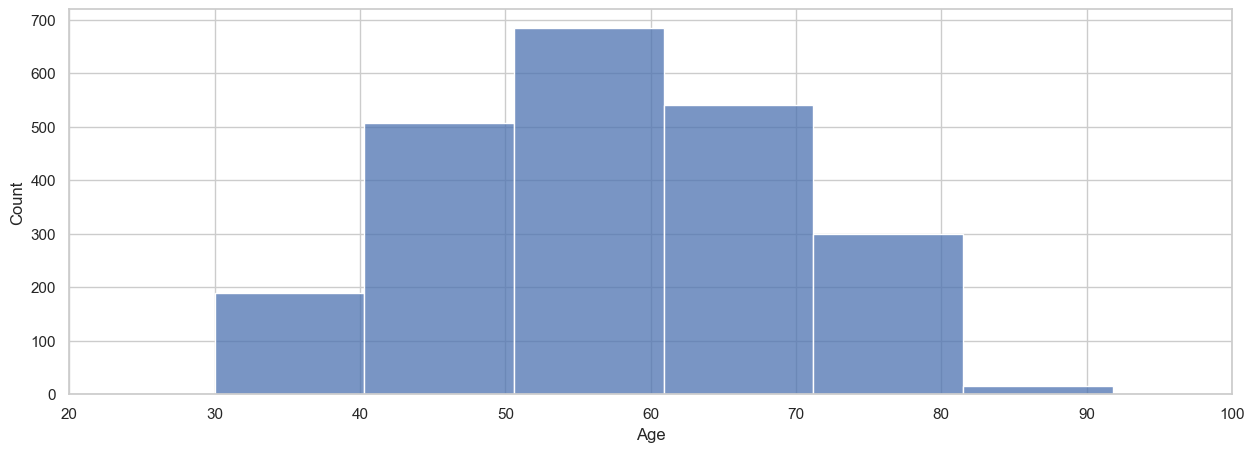

In [37]:
df["Age"] = 2026 - df["Year_Birth"]
# Plot a basic histogram
plt.figure(figsize=(15, 5))
age= sns.histplot(data=df, x= "Age", bins=10)
age.set_xlim(20, 100)
plt.show()

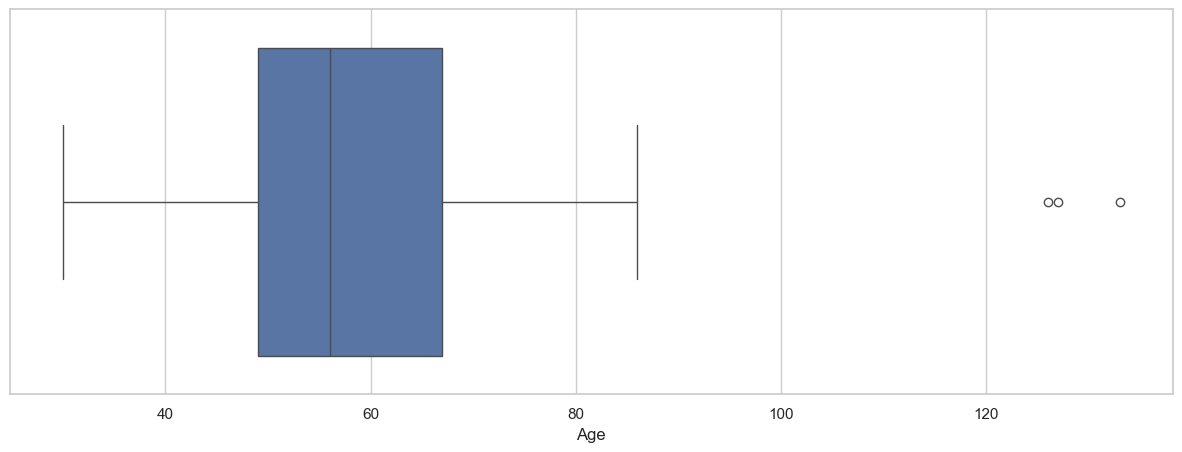

In [36]:
# Plot a basic histogram
plt.figure(figsize=(15, 5))
sns.boxplot(data=df, x= "Age")
plt.show()

<Axes: xlabel='Education', ylabel='count'>

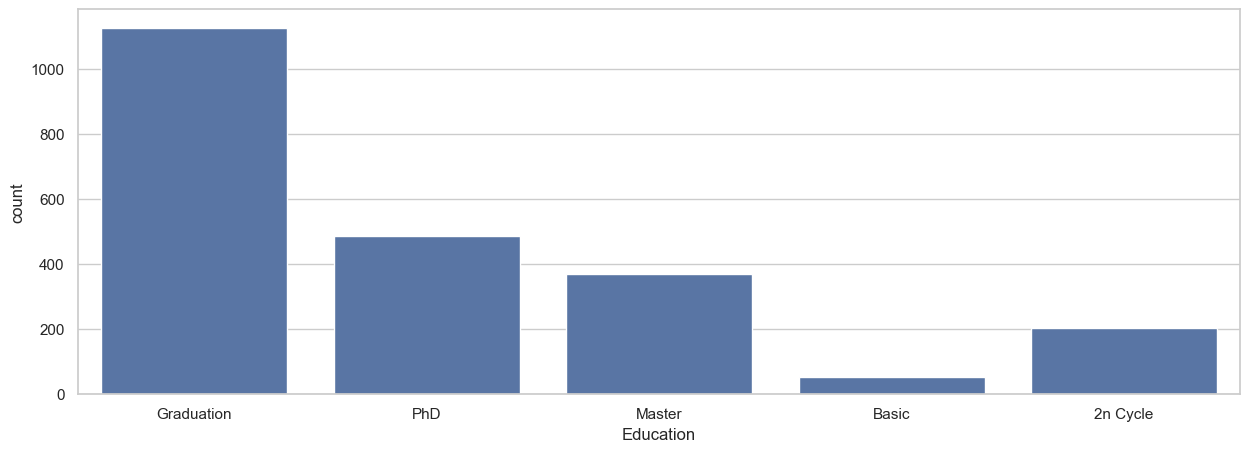

In [35]:
plt.figure(figsize=(15, 5))
sns.countplot(data=df, x="Education")

<Axes: xlabel='Marital_Status', ylabel='count'>

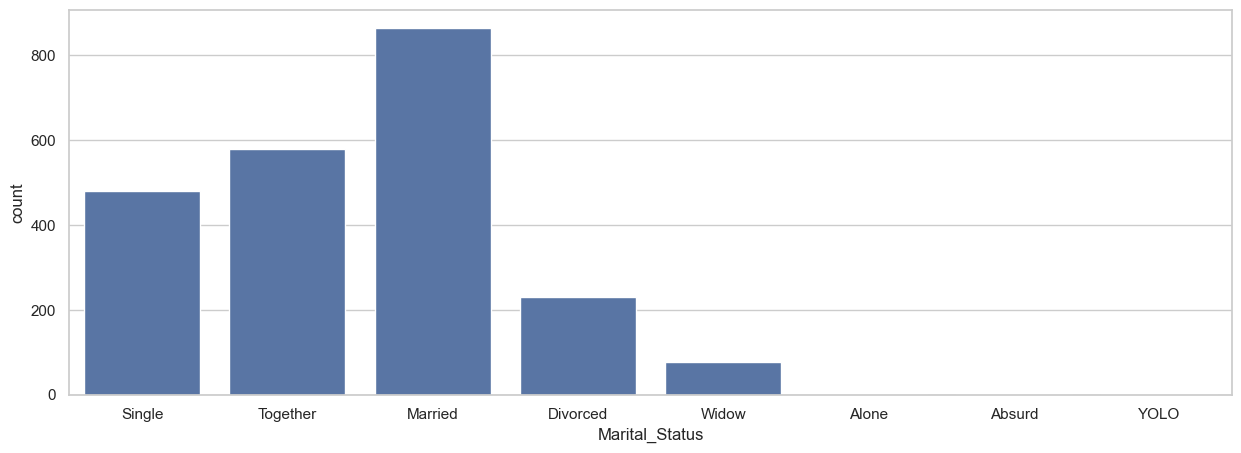

In [34]:
plt.figure(figsize=(15, 5))
sns.countplot(data=df, x="Marital_Status")

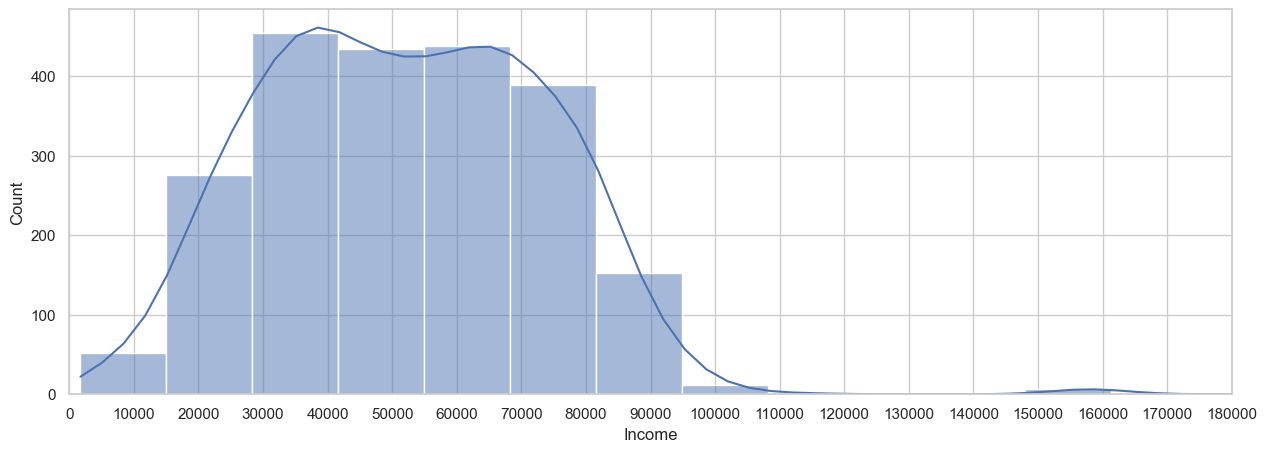

In [41]:
# Plot a basic histogram

import matplotlib.ticker as ticker
plt.figure(figsize=(15, 5))
icm = sns.histplot(data=df, x="Income", bins=50, kde= True)
icm.set_xlim(0, 180000)
icm.xaxis.set_major_locator(ticker.MultipleLocator(10000))

plt.show()

(0.0, 200000.0)

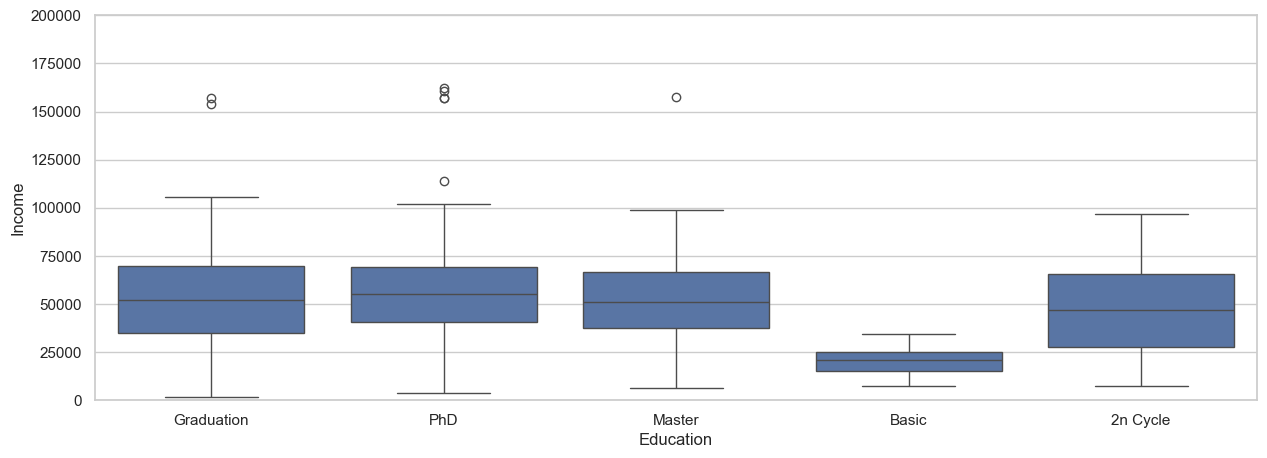

In [43]:
plt.figure(figsize=(15, 5))
eduInc= sns.boxplot(
    data=df,
    x="Education",
    y="Income"
)
eduInc.set_ylim(0, 200000)

##### Main Observations
* Customers are highly concentrated between **$50$ and $60$ years old**, representing the most prominent age group in the dataset.
* The majority of customers have a **Graduation-level** education and are **married**.
* Most customers have an annual **household income** between approximately **$\$30,000$ and $\$70,000$**.
* Customers with a **PhD education level** tend to have slightly **higher incomes** compared with customers from other education groups.

Overall, the customer base is primarily composed of **middle-aged, married customers with a Graduation-level education and moderate household income**. The slightly higher income observed among PhD customers may indicate a relationship between education level and purchasing power, which could be explored further in the segmentation analysis.

#### 4.6.2 Products Analysis
The main puspose is to understand purchasing behavior and product preferences, as well as answering important questions such as: Which products generate the highest spending? Are there any consumption patterns?

<Axes: >

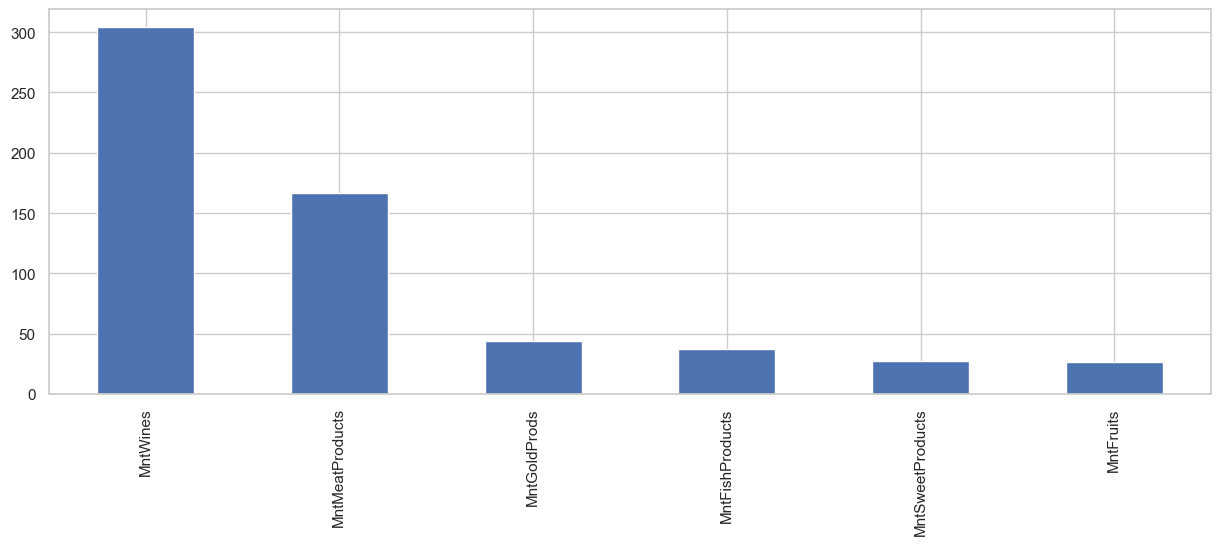

In [44]:
product_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]


plt.figure(figsize=(15, 5))
df[product_cols].mean().sort_values(ascending=False).plot.bar()

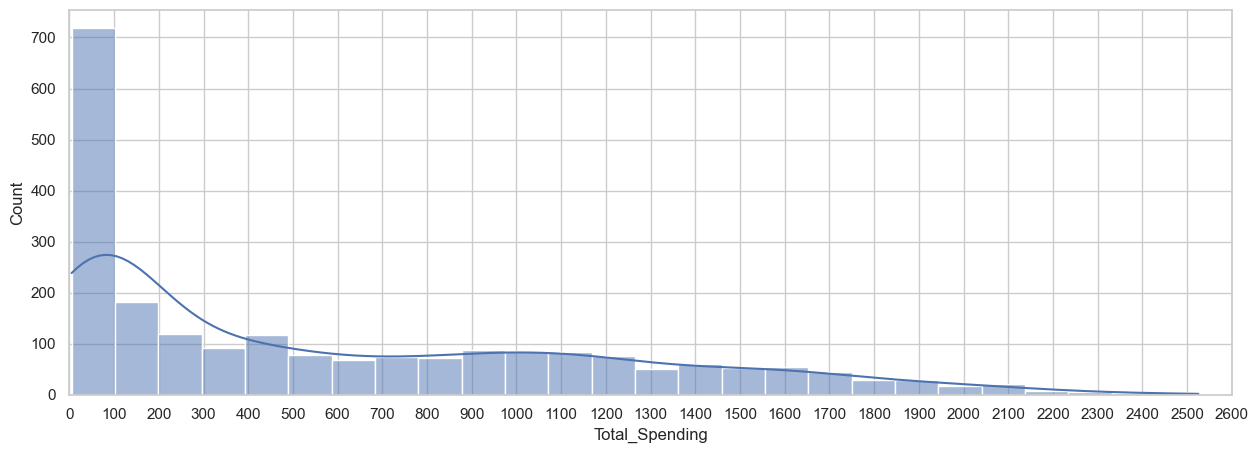

In [59]:
df["Total_Spending"] = df[product_cols].sum(axis=1)

plt.figure(figsize=(15, 5))
total_spend= sns.histplot(data=df, x="Total_Spending", bins= 26, kde= True)
total_spend.set_xlim(0, 2600)
total_spend.xaxis.set_major_locator(ticker.MultipleLocator(100))

##### Main Observations
* Wines are the most purchased product category, showing a clear preference for wine among the customers analyzed.
* Most customers have a relatively low total spending, with the majority spending less than $100 across the analyzed product categories.
* Overall, the customer base appears to be highly concentrated among lower-spending customers, while a smaller group accounts for substantially higher spending.

These findings suggest that wine represents an important product category within the customer base, while most customers exhibit relatively low overall spending. This spending pattern may be useful for identifying distinct customer segments based on purchasing behavior.

#### 4.6.3 Promotion Analysis
Understanding the respose of our clients for the current marketing strategies is important in order to take decisions regards it. We would like to have key information about which campaigns have a better acceptance and if customers are responsive to discounts.

In [61]:
# Calculate the percentage of customers who accepted each campaign

campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]

acceptance_rate = df[campaign_cols].mean() * 100

acceptance_rate

AcceptedCmp1     6.428571
AcceptedCmp2     1.339286
AcceptedCmp3     7.276786
AcceptedCmp4     7.455357
AcceptedCmp5     7.276786
Response        14.910714
dtype: float64

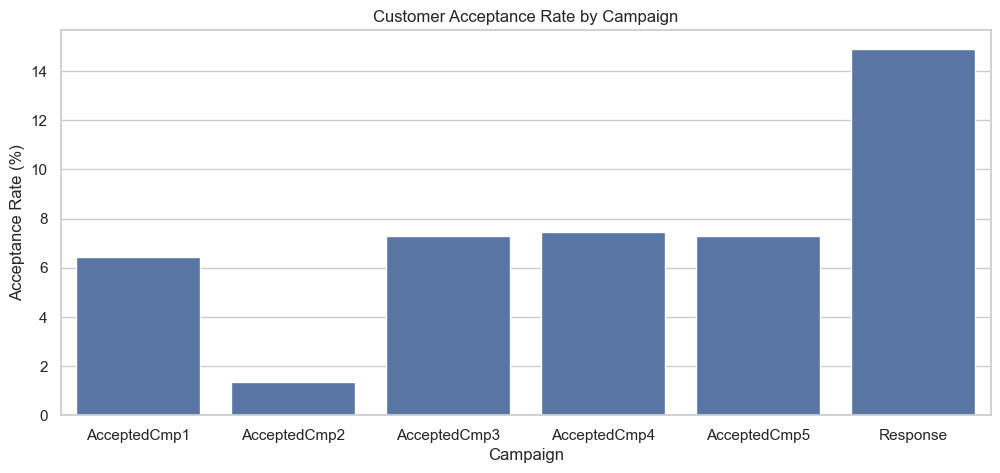

In [62]:
plt.figure(figsize=(12, 5))

sns.barplot(
    x=acceptance_rate.index,
    y=acceptance_rate.values
)

plt.xlabel("Campaign")
plt.ylabel("Acceptance Rate (%)")
plt.title("Customer Acceptance Rate by Campaign")

plt.show()

##### Main Observations
The last campaign was the most successful, as it achieved the highest customer acceptance. In contrast, the second campaign performed the worst, showing the lowest level of customer acceptance. Overall, these results suggest that the strategies used in the final campaign were more effective in engaging customers.


#### 4.6.4 Place Analysis
The main purpose for a place analysis is to understand purchasing channels and shopping behavior. Gives us information about the customer´s preferences between buying on stores, websites or catalogs, and how often they interact with each of them.